In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("online_retail.csv", encoding="latin1")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [4]:
df.dtypes


InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5268


In [8]:
df = df.dropna(subset=['CustomerID'])

print("Shape after removing missing CustomerID:", df.shape)

Shape after removing missing CustomerID: (406829, 8)


In [9]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

print("Shape after removing cancelled invoices:", df.shape)

Shape after removing cancelled invoices: (397924, 8)


In [10]:
df = df[df['Quantity'] > 0]

In [11]:
df = df[df['UnitPrice'] > 0]

In [12]:
df = df.drop_duplicates()

In [13]:
print("Final dataset shape:", df.shape)

Final dataset shape: (392692, 8)


In [14]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['InvoiceDate'].head()

0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[us]

In [15]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [16]:
df[['Quantity', 'UnitPrice', 'TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [17]:
df[['Quantity', 'UnitPrice', 'TotalAmount']].describe()

,Quantity,UnitPrice,TotalAmount
count,392692.000000,392692.000000,392692.000000
mean,13.119702,3.125914,22.631500
std,180.492832,22.241836,311.099224
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.450000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


In [18]:
print("Total Customers:", df['CustomerID'].nunique())
print("Total Transactions:", df['InvoiceNo'].nunique())
print("Total Revenue:", df['TotalAmount'].sum())
print("Average Purchase Value:", df['TotalAmount'].mean())

Total Customers: 4338
Total Transactions: 18532
Total Revenue: 8887208.894000001
Average Purchase Value: 22.631499735161402


In [19]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Snapshot Date:", snapshot_date)

Snapshot Date: 2011-12-10 12:50:00


In [20]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [21]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [22]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [23]:
print("Average Recency:", rfm['Recency'].mean())
print("Average Frequency:", rfm['Frequency'].mean())
print("Average Monetary:", rfm['Monetary'].mean())

Average Recency: 92.53642231443061
Average Frequency: 4.272014753342554
Average Monetary: 2048.688080682342


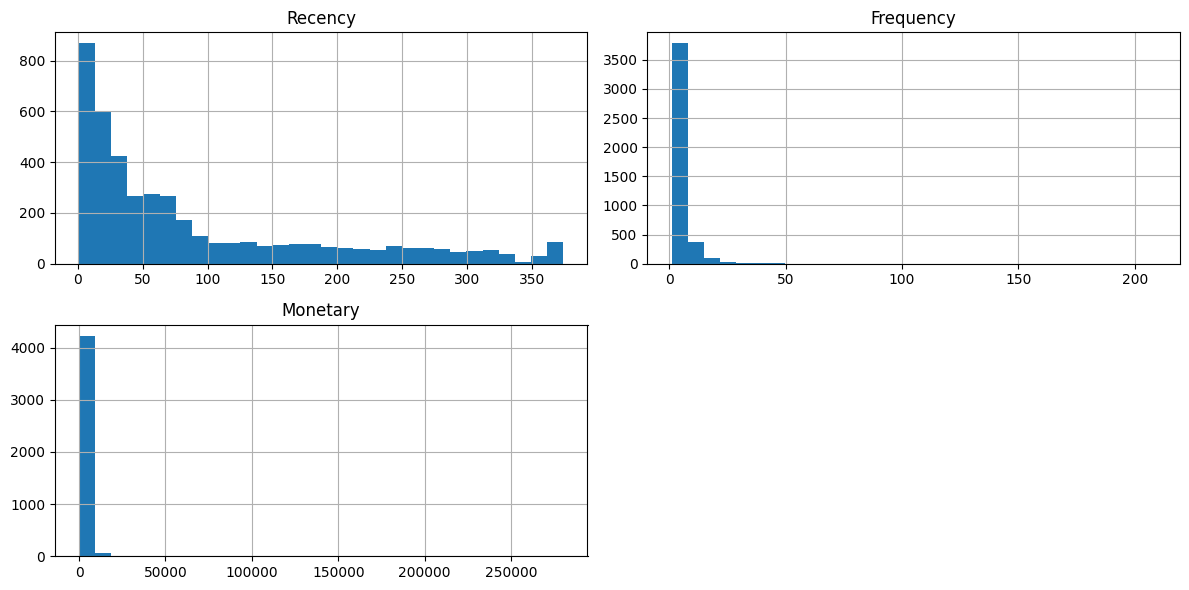

In [24]:
rfm[['Recency', 'Frequency', 'Monetary']].hist(
    figsize=(12, 6),
    bins=30
)

plt.tight_layout()
plt.show()

In [25]:
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return data[(data[column] >= lower) & (data[column] <= upper)]

In [26]:
rfm_clean = rfm.copy()

for col in ['Recency', 'Frequency', 'Monetary']:
    rfm_clean = remove_outliers(rfm_clean, col)

In [27]:
rfm_clean.describe()

,Recency,Frequency,Monetary
count,3604.000000,3604.000000,3604.000000
mean,91.591565,2.725305,810.507925
std,89.476857,2.078667,700.459846
min,1.000000,1.000000,3.750000
25%,22.000000,1.000000,286.565000
50%,57.000000,2.000000,576.980000
75%,144.250000,4.000000,1138.432500
max,327.000000,11.000000,3029.870000


In [28]:
features = rfm_clean[['Recency', 'Frequency', 'Monetary']]

In [29]:
features.head()

,Recency,Frequency,Monetary
CustomerID,,,
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
12352.0,36,8,2506.04
12353.0,204,1,89.00


In [30]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [31]:
scaled_rfm = pd.DataFrame(
    scaled_features,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=features.index
)

In [32]:
scaled_rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12348.0,-0.185454,0.613312,1.408887
12349.0,-0.811401,-0.830121,1.352217
12350.0,2.441288,-0.830121,-0.679802
12352.0,-0.621382,2.537889,2.420934
12353.0,1.256459,-0.830121,-1.030192


In [33]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(scaled_rfm)
    inertia.append(kmeans.inertia_)

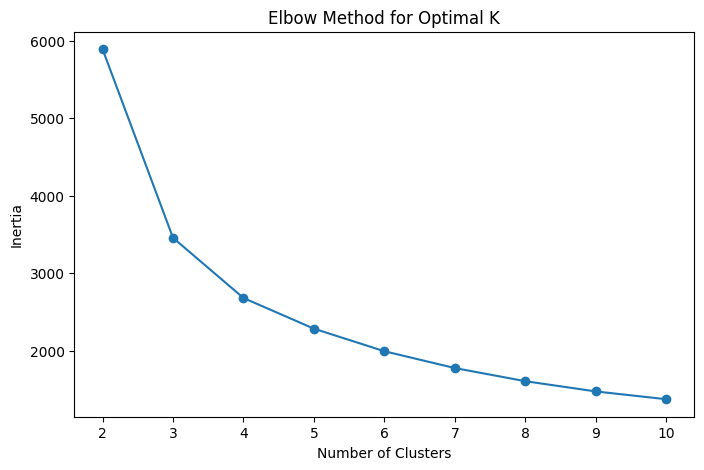

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker='o')

plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')

plt.show()

In [35]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(scaled_rfm)
    
    score = silhouette_score(scaled_rfm, labels)
    silhouette_scores.append(score)

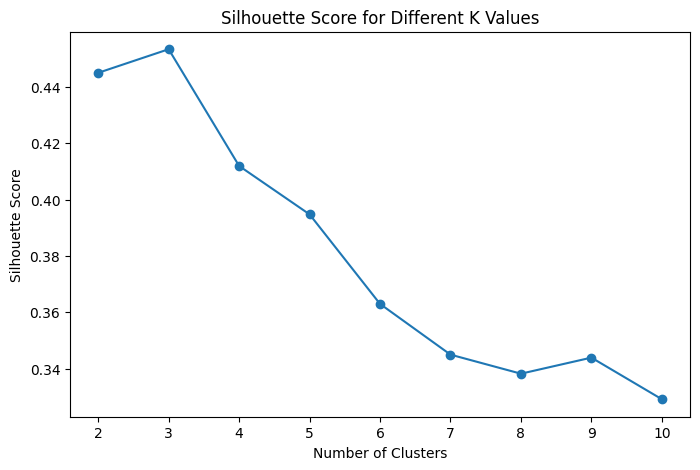

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K Values')

plt.show()

In [37]:
best_k = range(2, 11)[np.argmax(silhouette_scores)]

print("Best K:", best_k)

Best K: 3


In [38]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm_clean['Cluster'] = kmeans.fit_predict(scaled_rfm)

In [39]:
rfm_clean.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12348.0,75,4,1797.24,1
12349.0,19,1,1757.55,1
12350.0,310,1,334.40,2
12352.0,36,8,2506.04,3
12353.0,204,1,89.00,2


In [40]:
cluster_counts = rfm_clean['Cluster'].value_counts().sort_index()

print(cluster_counts)

Cluster
0    1435
1     861
2     872
3     436
Name: count, dtype: int64


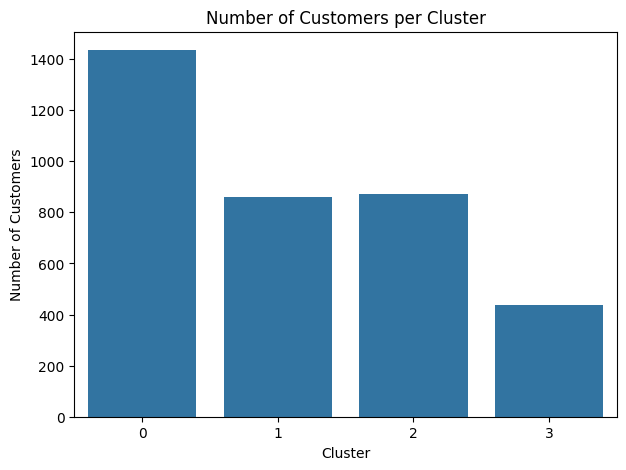

In [41]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Number of Customers per Cluster')

plt.show()

In [42]:
cluster_profile = rfm_clean.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
})

KeyError: "Label(s) ['CustomerID'] do not exist"

In [43]:
cluster_profile = cluster_profile.rename(
    columns={'CustomerID': 'CustomerCount'}
)

NameError: name 'cluster_profile' is not defined

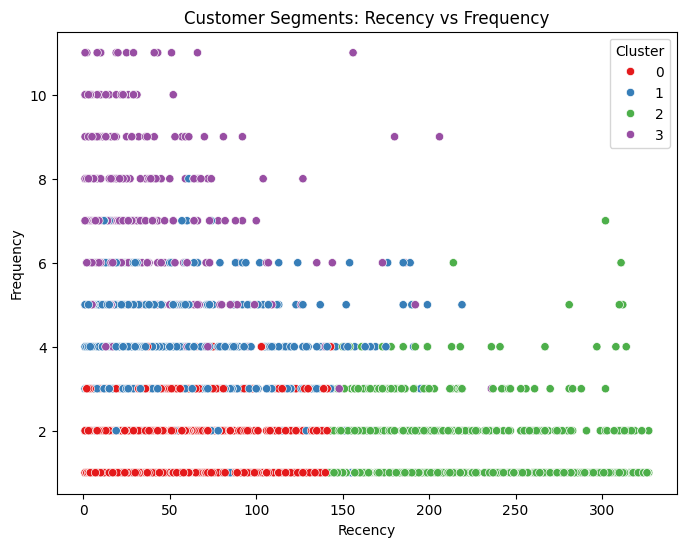

In [44]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm_clean,
    x='Recency',
    y='Frequency',
    hue='Cluster',
    palette='Set1'
)

plt.title('Customer Segments: Recency vs Frequency')
plt.xlabel('Recency')
plt.ylabel('Frequency')

plt.show()

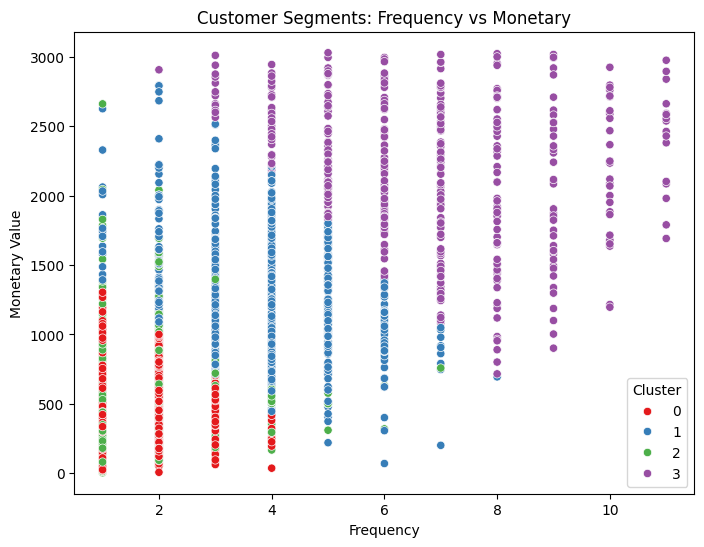

In [45]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm_clean,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set1'
)

plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Frequency')
plt.ylabel('Monetary Value')

plt.show()

In [46]:
profile = rfm_clean.groupby('Cluster')[
    ['Recency', 'Frequency', 'Monetary']
].mean()

In [47]:
profile = rfm_clean.groupby('Cluster')[
    ['Recency', 'Frequency', 'Monetary']
].mean()

In [48]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    profile_scaled,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title('Cluster Profile Heatmap')

plt.show()

NameError: name 'profile_scaled' is not defined

<Figure size 800x500 with 0 Axes>

In [49]:
segment_names = {
    0: 'Champions',
    1: 'At-Risk Customers',
    2: 'Loyal Customers',
    3: 'Potential Customers'
}

rfm_clean['Segment'] = rfm_clean['Cluster'].map(segment_names)

In [50]:
segment_summary = rfm_clean.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster': 'count'
}).rename(columns={'Cluster': 'Customers'})

segment_summary

,Recency,Frequency,Monetary,Customers
Segment,,,,
At-Risk Customers,46.623693,3.772358,1210.035936,861
Champions,51.971429,1.607666,410.991242,1435
Loyal Customers,231.008028,1.477064,398.081101,872
Potential Customers,31.961009,6.832569,2161.308417,436


## Marketing Recommendations

### Champions
These customers purchase recently, frequently and spend significantly. The company should retain them through VIP programs, exclusive offers, early product access and personalized recommendations.

### Loyal Customers
These customers purchase regularly and have good engagement. Loyalty points, membership benefits and personalized promotions can encourage them to continue purchasing.

### Potential Customers
These customers show moderate purchasing activity. Product recommendations, discounts and promotional campaigns can increase their purchase frequency and spending.

### At-Risk Customers
These customers have not purchased recently and may be becoming inactive. Win-back campaigns, personalized discounts and reminder emails can encourage them to return.

# Conclusion

K-Means clustering was successfully applied to segment customers based on Recency, Frequency and Monetary value. The analysis identified distinct customer groups with different purchasing behaviours.

The segmentation shows that highly engaged and high-value customers should be prioritized for retention and loyalty programs, while at-risk customers should receive targeted win-back campaigns. Potential customers can be encouraged through personalized offers and recommendations.

Overall, RFM-based customer segmentation can help an e-commerce company improve customer retention, personalize marketing campaigns and increase customer lifetime value.